In [4]:
!pip install kagglehub


   ---------------------------------------- 0/3 [pyyaml]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   -------------------------- ------------- 2/3 [kagglehub]
   -------------------------- ------------- 2/3 [kagglehub]
   ---------------------------------------- 3/3 [kagglehub]



In [5]:
import os
import glob
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [6]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [7]:
import kagglehub

path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Dataset path:", path)

META_PATH = os.path.join(path, "HAM10000_metadata.csv")
IMG_DIRS = [
    os.path.join(path, "HAM10000_images_part_1"),
    os.path.join(path, "HAM10000_images_part_2"),
]

df = pd.read_csv(META_PATH)
print("Rows loaded:", len(df))
df.head()

100%|██████████| 5.20G/5.20G [15:28<00:00, 6.01MB/s]

Extracting files...


Dataset path: C:\Users\hyj54\.cache\kagglehub\datasets\kmader\skin-cancer-mnist-ham10000\versions\2
Rows loaded: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [8]:
LABEL_MAP = {
    "akiec": "Actinic Keratoses / Intraepithelial Carcinoma",
    "bcc": "Basal Cell Carcinoma",
    "bkl": "Benign Keratosis",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic Nevi",
    "vasc": "Vascular Lesions",
}

MALIGNANT = {"mel", "bcc", "akiec"}

image_paths = {}
for d in IMG_DIRS:
    for fp in glob.glob(os.path.join(d, "*.jpg")):
        image_id = os.path.splitext(os.path.basename(fp))[0]
        image_paths[image_id] = fp

df["image_path"] = df["image_id"].map(image_paths)
df["dx_full"] = df["dx"].map(LABEL_MAP)
df["malignant"] = df["dx"].isin(MALIGNANT)

print("Missing image paths:", df["image_path"].isna().sum())
df = df.dropna(subset=["image_path"]).reset_index(drop=True)

print("Final rows:", len(df))
print(df["dx"].value_counts())

Missing image paths: 0
Final rows: 10015
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [9]:
CLASS_NAMES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
class_to_index = {cls: i for i, cls in enumerate(CLASS_NAMES)}
index_to_class = {i: cls for cls, i in class_to_index.items()}

df = df[df["dx"].isin(CLASS_NAMES)].copy()
df["label"] = df["dx"].map(class_to_index)

print("Class mapping:", class_to_index)
df[["dx", "label"]].head()

Class mapping: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


,dx,label
0,bkl,2
1,bkl,2
2,bkl,2
3,bkl,2
4,bkl,2


In [10]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))

print("\nTrain distribution:")
print(train_df["dx"].value_counts())

print("\nValidation distribution:")
print(val_df["dx"].value_counts())

print("\nTest distribution:")
print(test_df["dx"].value_counts())

Train size: 7010
Val size: 1502
Test size: 1503

Train distribution:
dx
nv       4693
mel       779
bkl       769
bcc       360
akiec     229
vasc       99
df         81
Name: count, dtype: int64

Validation distribution:
dx
nv       1006
mel       167
bkl       165
bcc        77
akiec      49
vasc       21
df         17
Name: count, dtype: int64

Test distribution:
dx
nv       1006
mel       167
bkl       165
bcc        77
akiec      49
vasc       22
df         17
Name: count, dtype: int64


In [11]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
NUM_CLASSES = len(CLASS_NAMES)
AUTOTUNE = tf.data.AUTOTUNE

In [12]:
def load_and_preprocess_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)  # ResNet50 preprocessing
    return image, tf.one_hot(label, depth=NUM_CLASSES)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

def build_dataset(dataframe, training=False):
    paths = dataframe["image_path"].values
    labels = dataframe["label"].values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)

    ds = ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=AUTOTUNE
        )

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = build_dataset(train_df, training=True)
val_ds = build_dataset(val_df, training=False)
test_ds = build_dataset(test_df, training=False)

print("Datasets built.")

Datasets built.


In [13]:
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.array(sorted(train_df["label"].unique())),
    y=train_df["label"].values
)

class_weights = {i: weight for i, weight in enumerate(class_weights_array)}
print("Class weights:", class_weights)

Class weights: {0: np.float64(4.37305053025577), 1: np.float64(2.7817460317460316), 2: np.float64(1.3022478172023035), 3: np.float64(12.36331569664903), 4: np.float64(1.285530900421786), 5: np.float64(0.21338772031292808), 6: np.float64(10.115440115440116)}


In [14]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,055 (91.99 MB)

 Trainable params: 526,343 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [15]:
checkpoint_cb = callbacks.ModelCheckpoint(
    "skin_cancer_resnet50_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

earlystop_cb = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_cb = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callback_list = [checkpoint_cb, earlystop_cb, reduce_lr_cb]

In [16]:
EPOCHS_STAGE_1 = 10

history_1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE_1,
    class_weight=class_weights,
    callbacks=callback_list,
    verbose=1
)

Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.3413 - loss: 2.2244
Epoch 1: val_accuracy improved from None to 0.33156, saving model to skin_cancer_resnet50_best.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 138s 611ms/step - accuracy: 0.3940 - loss: 1.8143 - val_accuracy: 0.3316 - val_loss: 1.7575 - learning_rate: 0.0010
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 523ms/step - accuracy: 0.4722 - loss: 1.4348
Epoch 2: val_accuracy improved from 0.33156 to 0.49268, saving model to skin_cancer_resnet50_best.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 141s 641ms/step - accuracy: 0.4816 - loss: 1.3872 - val_accuracy: 0.4927 - val_loss: 1.4298 - learning_rate: 0.0010
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - accuracy: 0.4967 - loss: 1.2483
Epoch 3: val_accuracy improved from 0.49268 to 0.64447, saving model to skin_cancer_resnet50_best.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 137s 622ms/step - accuracy: 0.5126 - loss: 1.2013 - val_accuracy: 0.6445 - val_loss: 1.0174 - learning_rate:

In [17]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

EPOCHS_STAGE_2 = 10
total_epochs = EPOCHS_STAGE_1 + EPOCHS_STAGE_2

history_2 = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=history_1.epoch[-1] + 1,
    epochs=total_epochs,
    class_weight=class_weights,
    callbacks=callback_list,
    verbose=1
)

Epoch 9/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 635ms/step - accuracy: 0.6042 - loss: 1.8542
Epoch 9: val_accuracy did not improve from 0.64447
220/220 ━━━━━━━━━━━━━━━━━━━━ 168s 738ms/step - accuracy: 0.6000 - loss: 1.5347 - val_accuracy: 0.5979 - val_loss: 1.1361 - learning_rate: 1.0000e-05
Epoch 10/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 0.6047 - loss: 1.1765
Epoch 10: val_accuracy did not improve from 0.64447

Epoch 10: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
220/220 ━━━━━━━━━━━━━━━━━━━━ 159s 722ms/step - accuracy: 0.5967 - loss: 1.1001 - val_accuracy: 0.5573 - val_loss: 1.2464 - learning_rate: 1.0000e-05
Epoch 11/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - accuracy: 0.5731 - loss: 0.9753
Epoch 11: val_accuracy did not improve from 0.64447
220/220 ━━━━━━━━━━━━━━━━━━━━ 162s 733ms/step - accuracy: 0.5862 - loss: 0.9847 - val_accuracy: 0.5519 - val_loss: 1.2851 - learning_rate: 3.0000e-06
Epoch 12/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 622ms/ste

In [18]:
model.save("skin_cancer_resnet50.keras")
print("Final model saved as skin_cancer_resnet50.keras")

Final model saved as skin_cancer_resnet50.keras


In [19]:
acc = history_1.history["accuracy"] + history_2.history["accuracy"]
val_acc = history_1.history["val_accuracy"] + history_2.history["val_accuracy"]
loss = history_1.history["loss"] + history_2.history["loss"]
val_loss = history_1.history["val_loss"] + history_2.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

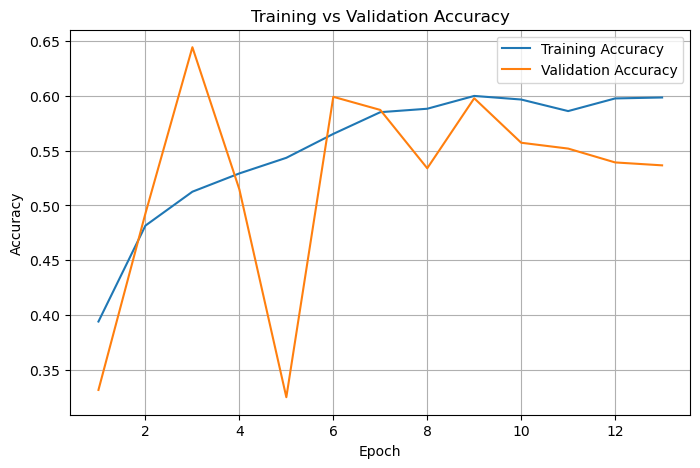

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

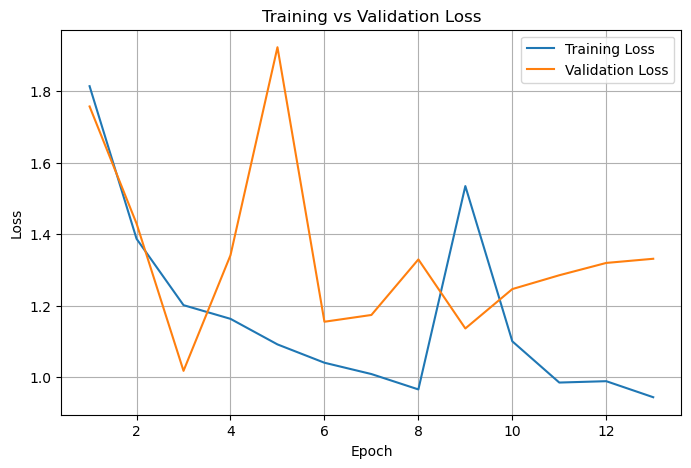

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 457ms/step - accuracy: 0.5642 - loss: 1.2155
Test Loss: 1.2155
Test Accuracy: 0.5642


In [23]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [24]:
report = classification_report(
    y_true,
    y_pred,
    target_names=[LABEL_MAP[c] for c in CLASS_NAMES],
    digits=4
)
print(report)

                                               precision    recall  f1-score   support

Actinic Keratoses / Intraepithelial Carcinoma     0.1818    0.2041    0.1923        49
                         Basal Cell Carcinoma     0.2537    0.6623    0.3669        77
                             Benign Keratosis     0.2661    0.5273    0.3537       165
                               Dermatofibroma     0.1215    0.7647    0.2097        17
                                     Melanoma     0.5625    0.0539    0.0984       167
                             Melanocytic Nevi     0.8916    0.6620    0.7598      1006
                             Vascular Lesions     0.2400    0.5455    0.3333        22

                                     accuracy                         0.5642      1503
                                    macro avg     0.3596    0.4885    0.3306      1503
                                 weighted avg     0.7123    0.5642    0.5907      1503



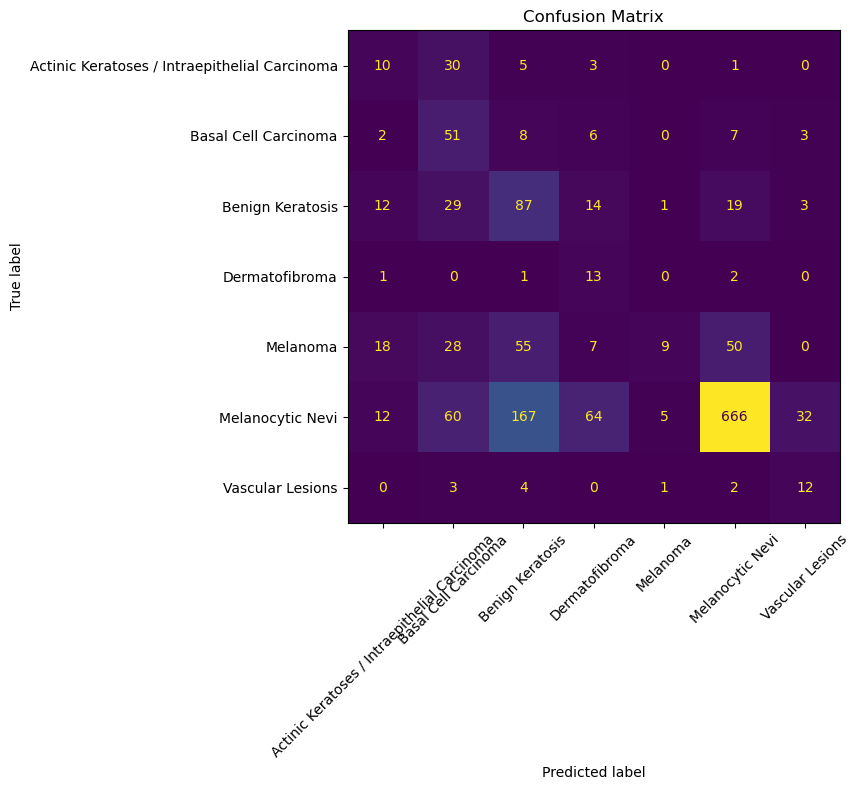

In [25]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[LABEL_MAP[c] for c in CLASS_NAMES]
)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [26]:
malignant_classes = {"mel", "bcc", "akiec"}

y_true_binary = np.array([
    1 if CLASS_NAMES[idx] in malignant_classes else 0
    for idx in y_true
])

y_pred_binary = np.array([
    1 if CLASS_NAMES[idx] in malignant_classes else 0
    for idx in y_pred
])

print("Malignant vs Benign Report:")
print(classification_report(
    y_true_binary,
    y_pred_binary,
    target_names=["Benign", "Malignant"],
    digits=4
))

Malignant vs Benign Report:
              precision    recall  f1-score   support

      Benign     0.8822    0.8975    0.8898      1210
   Malignant     0.5441    0.5051    0.5239       293

    accuracy                         0.8210      1503
   macro avg     0.7132    0.7013    0.7068      1503
weighted avg     0.8163    0.8210    0.8185      1503

